<a href="https://colab.research.google.com/github/nadiaannisa58-afk/dengue-forecasting-indonesia/blob/main/5_layer_DBD_%26_iklim_lokal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset

!cp "/content/drive/MyDrive/hasil_data_gabungan_DBD_iklim lokal.csv" "./data.csv"
df = pd.read_csv("data.csv")

# Clean and convert data to numeric
for col in ["Kasus DBD", "Curah Hujan", "Kelembapan", "Suhu"]:
    df[col] = df[col].astype(str).str.replace(",", "").str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)

# Create time series sequences
def create_sequences(data, n_steps=2):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps, 1:])  # Features
        y.append(data[i+n_steps, 0])     # Target
    return np.array(X), np.array(y)

# Inverse transform function
def inverse_scale(preds, scaler):
    dummy = np.zeros((len(preds), 3))
    return scaler.inverse_transform(np.hstack((preds, dummy)))[:, 0]

# Model configuration
n_steps = 2
performance_results = []
provinces = df["Nama Provinsi"].unique()

training_histories = {}
for province in provinces:
    print(f"\nProcessing: {province}")
    df_prov = df[df["Nama Provinsi"] == province].sort_values("Tahun").copy()

    if len(df_prov) < 5:
        print(f"Skipping {province} due to insufficient data.")
        continue

    # Normalize data
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df_prov[["Kasus DBD", "Curah Hujan", "Kelembapan", "Suhu"]])

    X, y = create_sequences(scaled, n_steps)
    if len(X) < 1:
        print(f"Skipping {province} due to insufficient sequences.")
        continue

    # Split data
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Define 5-layer LSTM model
    model = Sequential()
    model.add(LSTM(8, return_sequences=True, input_shape=(n_steps, X.shape[2])))
    model.add(Dropout(0.2))
    model.add(LSTM(24, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(16, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(16, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(8))  # Final LSTM without return_sequences
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='linear'))

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    # Fit model
    early_stop = EarlyStopping(monitor='val_loss', patience=550, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=4000, batch_size=1, verbose=0,
              callbacks=[early_stop], validation_data=(X_test, y_test))
    training_histories[province] = history.history

    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_inv = inverse_scale(y_train.reshape(-1,1), scaler)
    y_train_pred_inv = inverse_scale(y_train_pred, scaler)
    y_test_inv = inverse_scale(y_test.reshape(-1,1), scaler)
    y_test_pred_inv = inverse_scale(y_test_pred, scaler)

    # Metrics
    train_rmse = math.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv))
    train_mae = mean_absolute_error(y_train_inv, y_train_pred_inv)
    test_rmse = math.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))
    test_mae = mean_absolute_error(y_test_inv, y_test_pred_inv)
    train_r2 = r2_score(y_train_inv, y_train_pred_inv)
    test_r2 = r2_score(y_test_inv, y_test_pred_inv)

    performance_results.append({
        'Province': province,
        'Model': 'LSTM_5Layers',
        'Train RMSE': train_rmse,
        'Train MAE': train_mae,
        'Train R2': train_r2,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Test R2': test_r2
    })

# Save results
performance_df = pd.DataFrame(performance_results)
# performance_df.to_csv("performance_results_per_province.csv", index=False)
print("\nPerformance Summary:")
print(performance_df)

import matplotlib.pyplot as plt
import os

# Pastikan folder penyimpanan ada
drive_output_dir = "/content/drive/MyDrive/DATA/plots_loss_DBD_5layer_iklim lokal"
os.makedirs(drive_output_dir, exist_ok=True)

# Loop untuk setiap provinsi yang ada di training_histories
for prov, hist in training_histories.items():
    plt.figure(figsize=(6, 4))
    plt.plot(hist['loss'], label='Train')
    plt.plot(hist['val_loss'], label='Validation')
    plt.title(f"Model loss - {prov}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Buat nama file yang rapi
    filename = prov.replace(" ", "_").replace("/", "_")
    path = os.path.join(drive_output_dir, f"loss_5 layer_DBD & iklim lokal_{filename}.png")
    plt.savefig(path)
    plt.close()

print(f"✅ Semua grafik model loss disimpan ke: {drive_output_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Processing: ACEH


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step

Processing: SUMATERA UTARA


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 926ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Processing: SUMATERA BARAT


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Processing: PAPUA BARAT


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step

Processing: PAPUA


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 919ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Performance Summary:
                Province         Model   Train RMSE    Train MAE  Train R2  \
0                   ACEH  LSTM_5Layers   704.373111   592.232336 -0.447019   
1         SUMATERA UTARA  LSTM_5Layers   978.555756   817.475312  0.670809   
2         SUMATERA BARAT  LSTM_5Layers   874.097965   628.214127 -0.074684   
3                   RIAU  LSTM_5Layers  1271.081804  1059.519494 -0.192537   
4                  JAMBI  LSTM_5Layers   463.700828   435.377081  0.312599   
5       SUMATERA SELATAN  LSTM_5Layers   849.453229   713.476492  0.006226   
6               BENGKULU  LSTM_5Layers   342.122290   264.262067  0.414388   
7                LAMPUNG  LSTM_5Layers  1763.822750  1438.750836 -0.356746   
8   KEP. BANGKA BELITUNG  LSTM_5Layers   230.191368   195.166303  0.420668   
9              KEP. RIAU  LSTM_5Layers   391.321672   342.368888  0.198903   
10           DKI JAKARTA  LSTM_5Layers  5787.

In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset

!cp "/content/drive/MyDrive/hasil_data_gabungan_DBD_iklim lokal.csv" "./data.csv"
df = pd.read_csv("data.csv")

# Clean and convert data to numeric
for col in ["Kasus DBD", "Curah Hujan", "Kelembapan", "Suhu"]:
    df[col] = df[col].astype(str).str.replace(",", "").str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)

# Create time series sequences
def create_sequences(data, n_steps=2):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps, 1:])  # Features
        y.append(data[i+n_steps, 0])     # Target
    return np.array(X), np.array(y)

# Inverse transform function
def inverse_scale(preds, scaler):
    dummy = np.zeros((len(preds), 3))
    return scaler.inverse_transform(np.hstack((preds, dummy)))[:, 0]

# Model configuration
n_steps = 2
performance_results = []
provinces = df["Nama Provinsi"].unique()

training_histories = {}
for province in provinces:
  if province  == "NUSA TENGGARA TIMUR":
    print(f"\nProcessing: {province}")
    df_prov = df[df["Nama Provinsi"] == province].sort_values("Tahun").copy()

    if len(df_prov) < 5:
        print(f"Skipping {province} due to insufficient data.")
        continue

    # Normalize data
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df_prov[["Kasus DBD", "Curah Hujan", "Kelembapan", "Suhu"]])

    X, y = create_sequences(scaled, n_steps)
    if len(X) < 1:
        print(f"Skipping {province} due to insufficient sequences.")
        continue

    # Split data
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Define 5-layer LSTM model
    model = Sequential()
    model.add(LSTM(4, activation='relu', return_sequences=True, input_shape=(n_steps, X.shape[2])))
    model.add(Dropout(0.2))
    model.add(LSTM(8, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(12, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(8, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(4))  # Final LSTM without return_sequences
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='linear'))

    model.compile(optimizer=Adam(learning_rate=0.05), loss='mse')

    # Fit model
    early_stop = EarlyStopping(monitor='val_loss', patience=300, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=5000, batch_size=1, verbose=0,
              callbacks=[early_stop], validation_data=(X_test, y_test))
    training_histories[province] = history.history

    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_inv = inverse_scale(y_train.reshape(-1,1), scaler)
    y_train_pred_inv = inverse_scale(y_train_pred, scaler)
    y_test_inv = inverse_scale(y_test.reshape(-1,1), scaler)
    y_test_pred_inv = inverse_scale(y_test_pred, scaler)

    # Metrics
    train_rmse = math.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv))
    train_mae = mean_absolute_error(y_train_inv, y_train_pred_inv)
    test_rmse = math.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))
    test_mae = mean_absolute_error(y_test_inv, y_test_pred_inv)
    train_r2 = r2_score(y_train_inv, y_train_pred_inv)
    test_r2 = r2_score(y_test_inv, y_test_pred_inv)

    performance_results.append({
        'Province': province,
        'Model': 'LSTM_5Layers',
        'Train RMSE': train_rmse,
        'Train MAE': train_mae,
        'Train R2': train_r2,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Test R2': test_r2
    })

# Save results
performance_df = pd.DataFrame(performance_results)
# performance_df.to_csv("performance_results_per_province.csv", index=False)
print("\nPerformance Summary:")
print(performance_df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Processing: NUSA TENGGARA TIMUR


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 793ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 813ms/step

Performance Summary:
              Province         Model   Train RMSE    Train MAE  Train R2  \
0  NUSA TENGGARA TIMUR  LSTM_5Layers  2103.277352  2004.894775 -0.234873   

    Test RMSE    Test MAE   Test R2  
0  310.203584  214.855113 -0.662775  


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Processing: SUMATERA UTARA


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step

Processing: SUMATERA BARAT


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step

Processing: SULAWESI BARAT


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step

Processing: MALUKU


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step

Performance Summary:
              Province         Model   Train RMSE    Train MAE  Train R2  \
0       SUMATERA UTARA  LSTM_5Layers  1424.732830  1169.411742  0.302180   
1       SUMATERA BARAT  LSTM_5Layers   429.950930   323.827759  0.739985   
2                 RIAU  LSTM_5Layers   204.836464   169.005034  0.969030   
3                JAMBI  LSTM_5Layers   470.653321   377.509754  0.291831   
4     SUMATERA SELATAN  LSTM_5Layers   326.255984   255.213087  0.853403   
5             BENGKULU  LSTM_5Layers   176.145978   110.472047  0.844764   
6              LAMPUNG  LSTM_5Layers   580.544355   481.710137  0.853020   
7          DKI JAKARTA  LSTM_5Layers  3237.961728  2385.410485  0.586170   
8          JAWA TENGAH  LSTM_5Layers  1822.424739  1550.332891  0.823612   
9           JAWA TIMUR  LSTM_5Layers  3511.984114  2401.378265  0.651443   
10    KALIMANTAN BARAT  LSTM_5Layers   447.788919   421.022992  

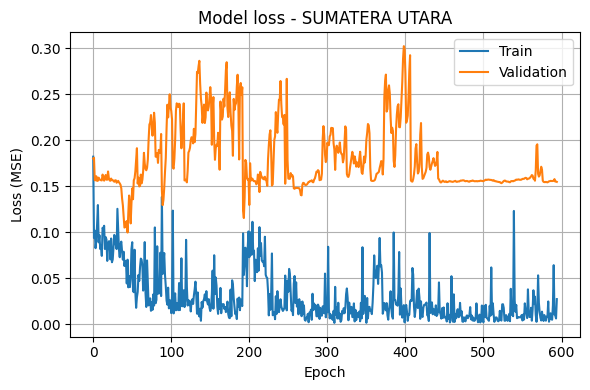

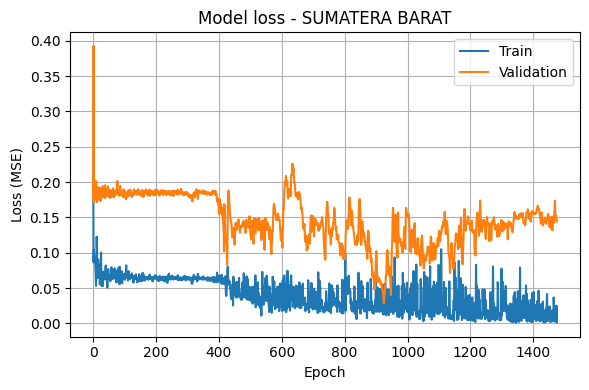

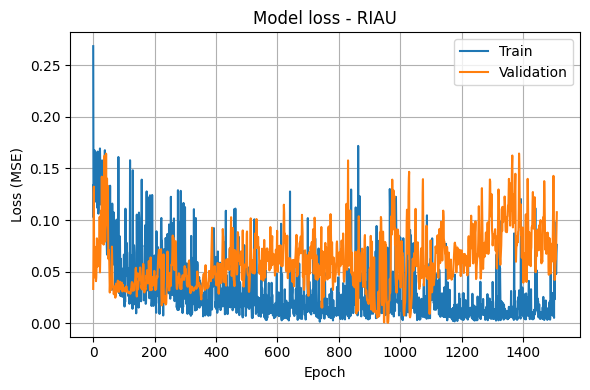

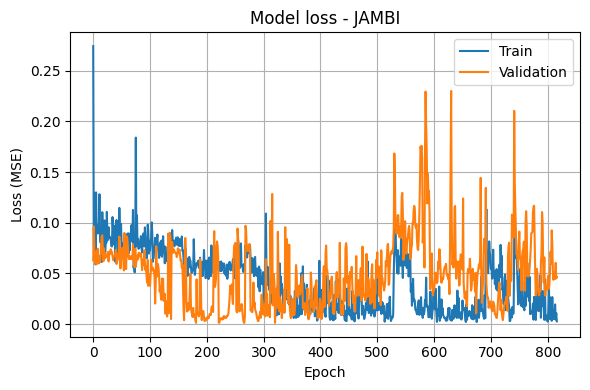

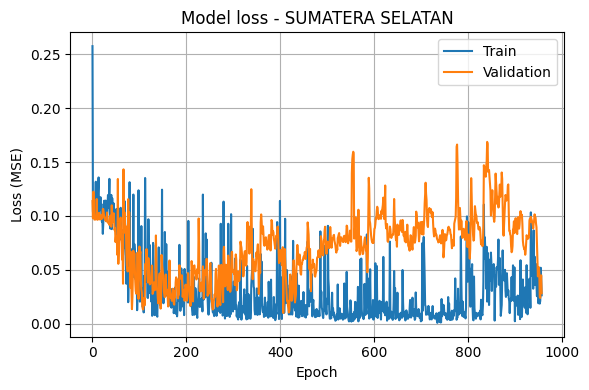

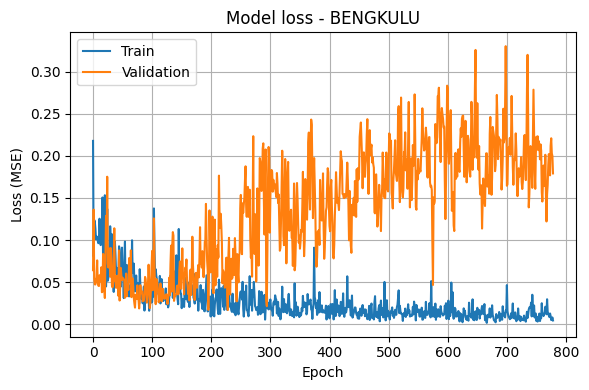

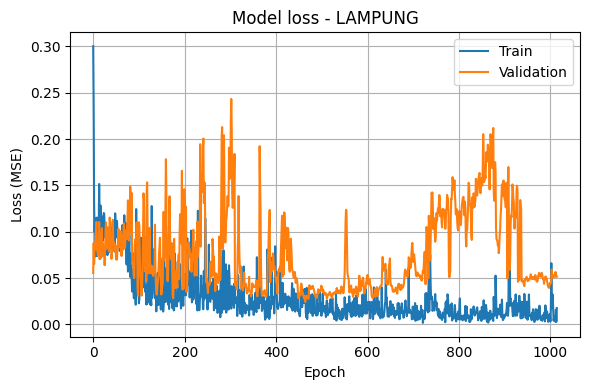

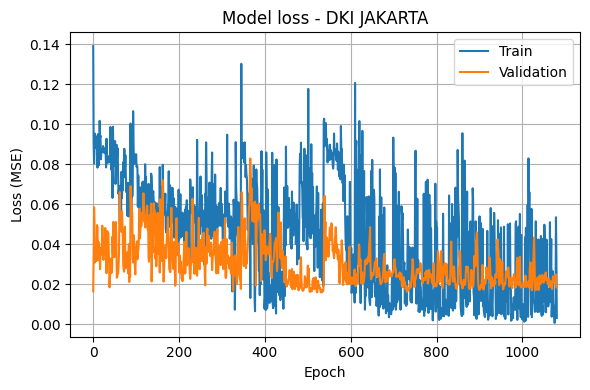

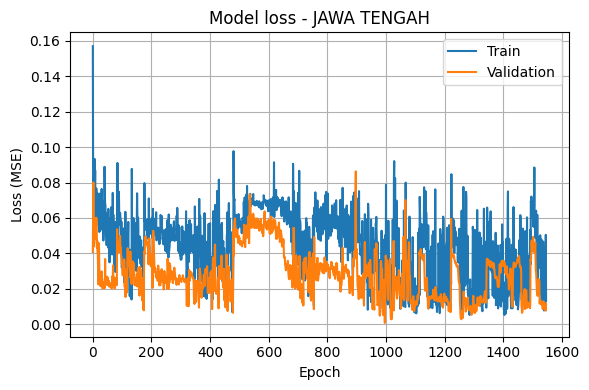

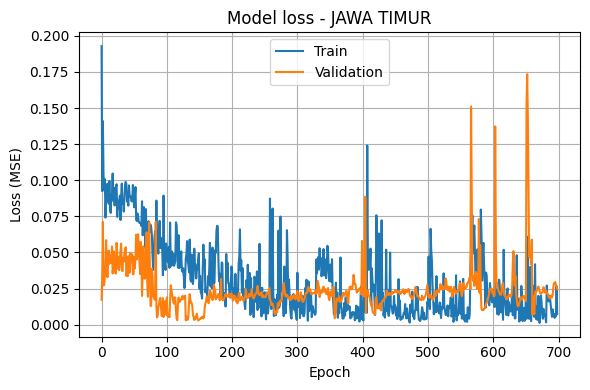

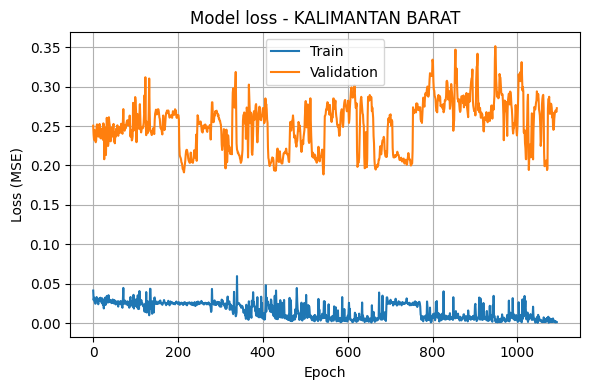

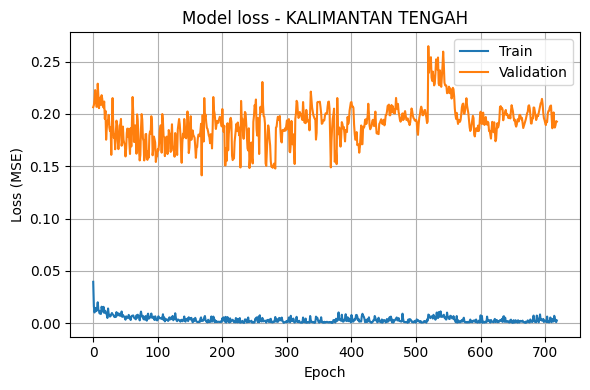

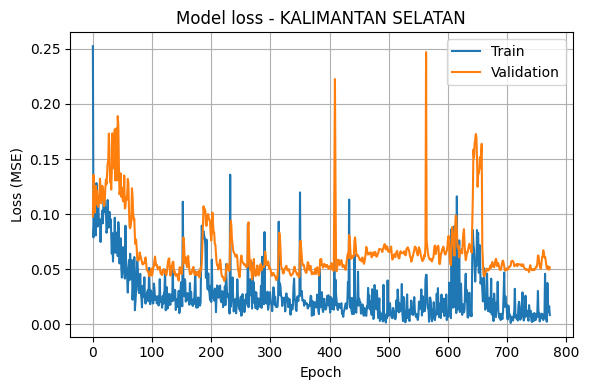

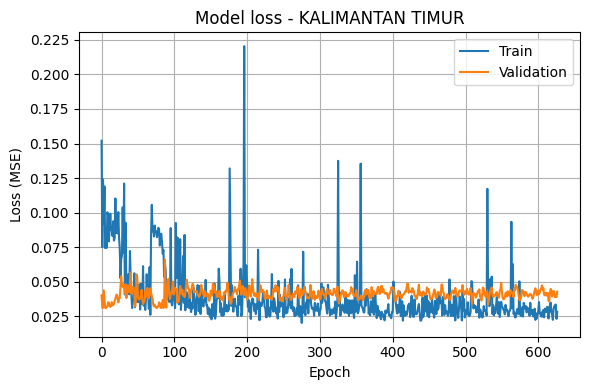

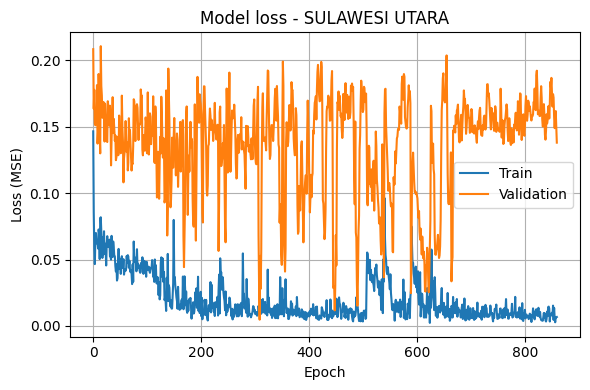

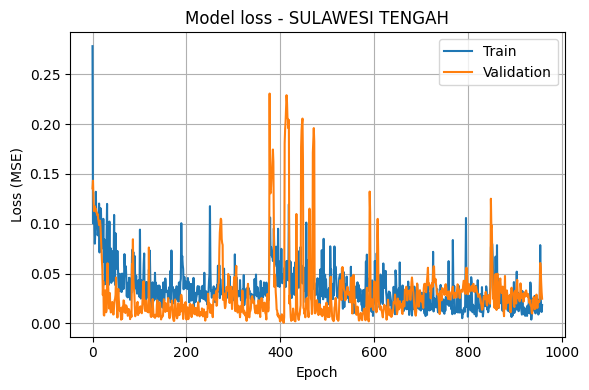

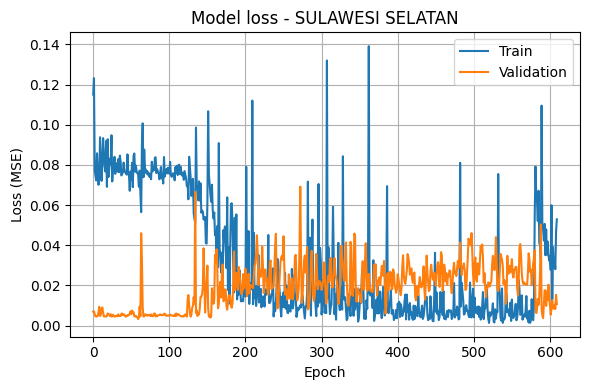

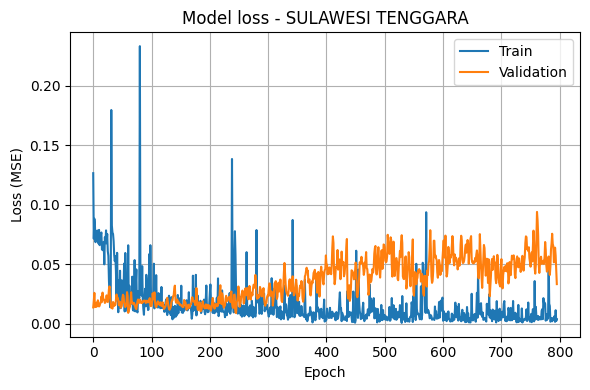

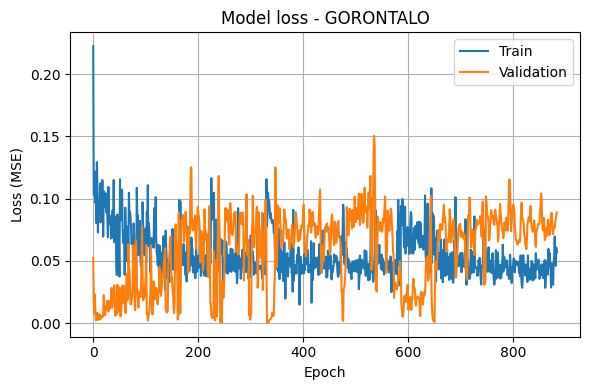

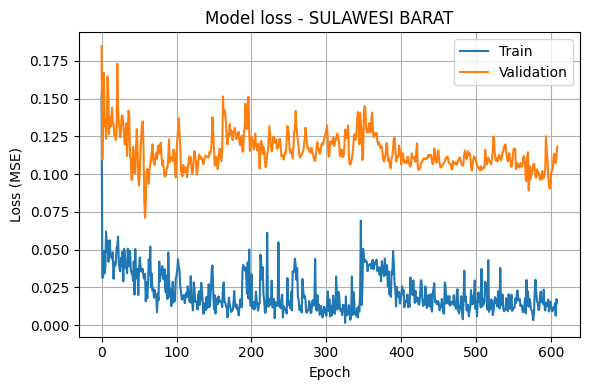

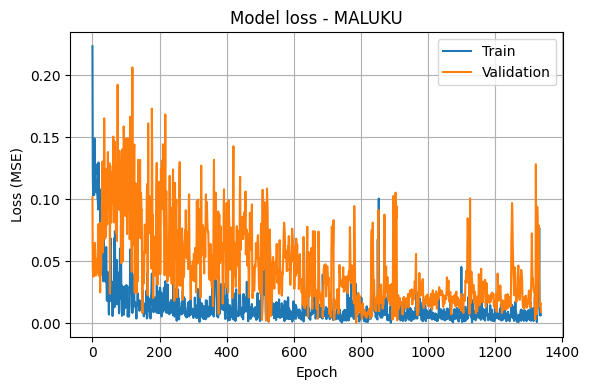

In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset

!cp "/content/drive/MyDrive/hasil_data_gabungan_DBD_iklim lokal.csv" "./data.csv"
df = pd.read_csv("data.csv")

# Clean and convert data to numeric
for col in ["Kasus DBD", "Curah Hujan", "Kelembapan", "Suhu"]:
    df[col] = df[col].astype(str).str.replace(",", "").str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)

# Create time series sequences
def create_sequences(data, n_steps=2):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps, 1:])  # Features
        y.append(data[i+n_steps, 0])     # Target
    return np.array(X), np.array(y)

# Inverse transform function
def inverse_scale(preds, scaler):
    dummy = np.zeros((len(preds), 3))
    return scaler.inverse_transform(np.hstack((preds, dummy)))[:, 0]

# Model configuration
n_steps = 2
performance_results = []
provinces = df["Nama Provinsi"].unique()

training_histories = {}
for province in provinces:
  # if province == "MALUKU":
  if province == "SUMATERA UTARA" or province == "SUMATERA BARAT" or province == "RIAU" or province == "JAMBI"or province == "SUMATERA SELATAN"or province == "BENGKULU"or province == "LAMPUNG"or province == "KEP RIAU"or province == "DKI JAKARTA"or province == "JAWA TENGAH"or province == "JAWA TIMUR"or province == "KALIMANTAN BARAT"or province == "KALIMANTAN TENGAH"or province == "KALIMANTAN SELATAN"or province == "KALIMANTAN TIMUR"or province == "SULAWESI UTARA"or province == "SULAWESI SELATAN"or province == "SULAWESI TENGAH"or province == "SULAWESI TENGGARA"or province == "GORONTALO"or province == "SULAWESI BARAT"or province == "MALUKU":
    print(f"\nProcessing: {province}")
    df_prov = df[df["Nama Provinsi"] == province].sort_values("Tahun").copy()

    if len(df_prov) < 5:
        print(f"Skipping {province} due to insufficient data.")
        continue

    # Normalize data
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df_prov[["Kasus DBD", "Curah Hujan", "Kelembapan", "Suhu"]])

    X, y = create_sequences(scaled, n_steps)
    if len(X) < 1:
        print(f"Skipping {province} due to insufficient sequences.")
        continue

    # Split data
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Define 5-layer LSTM model
    model = Sequential()
    model.add(LSTM(8, activation='relu', return_sequences=True, input_shape=(n_steps, X.shape[2])))
    model.add(Dropout(0.2))
    model.add(LSTM(24, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(16, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(16, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(8))  # Final LSTM without return_sequences
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='linear'))

    model.compile(optimizer=Adam(learning_rate=0.0095), loss='mse')

    # Fit model
    early_stop = EarlyStopping(monitor='val_loss', patience=550, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=4000, batch_size=1, verbose=0,
              callbacks=[early_stop], validation_data=(X_test, y_test))
    training_histories[province] = history.history

    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_inv = inverse_scale(y_train.reshape(-1,1), scaler)
    y_train_pred_inv = inverse_scale(y_train_pred, scaler)
    y_test_inv = inverse_scale(y_test.reshape(-1,1), scaler)
    y_test_pred_inv = inverse_scale(y_test_pred, scaler)

    # Metrics
    train_rmse = math.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv))
    train_mae = mean_absolute_error(y_train_inv, y_train_pred_inv)
    test_rmse = math.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))
    test_mae = mean_absolute_error(y_test_inv, y_test_pred_inv)
    train_r2 = r2_score(y_train_inv, y_train_pred_inv)
    test_r2 = r2_score(y_test_inv, y_test_pred_inv)

    performance_results.append({
        'Province': province,
        'Model': 'LSTM_5Layers',
        'Train RMSE': train_rmse,
        'Train MAE': train_mae,
        'Train R2': train_r2,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Test R2': test_r2
    })

# Save results
performance_df = pd.DataFrame(performance_results)
# performance_df.to_csv("performance_results_per_province.csv", index=False)
print("\nPerformance Summary:")
print(performance_df)

# Loop untuk setiap provinsi yang ada di training_histories
for prov, hist in training_histories.items():
    plt.figure(figsize=(6, 4))
    plt.plot(hist['loss'], label='Train')
    plt.plot(hist['val_loss'], label='Validation')
    plt.title(f"Model loss - {prov}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Tampilkan plot
    plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Processing: KALIMANTAN TIMUR


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step

Processing: GORONTALO


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step

Performance Summary:
           Province         Model  Train RMSE   Train MAE  Train R2  \
0  KALIMANTAN TIMUR  LSTM_5Layers  893.653466  669.442254  0.910520   
1         GORONTALO  LSTM_5Layers  271.938465  210.893717  0.414666   

   Test RMSE   Test MAE   Test R2  
0  51.689473  41.320537  0.999196  
1  17.004479  12.827659  0.903666  


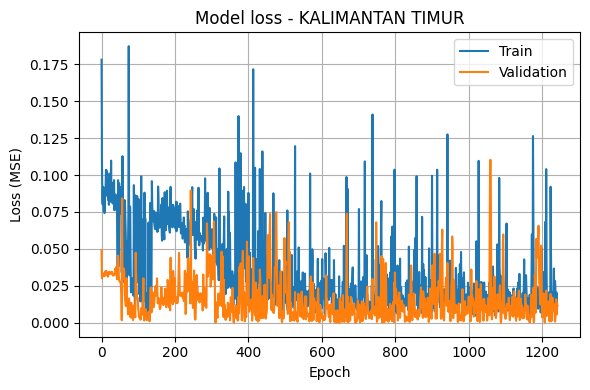

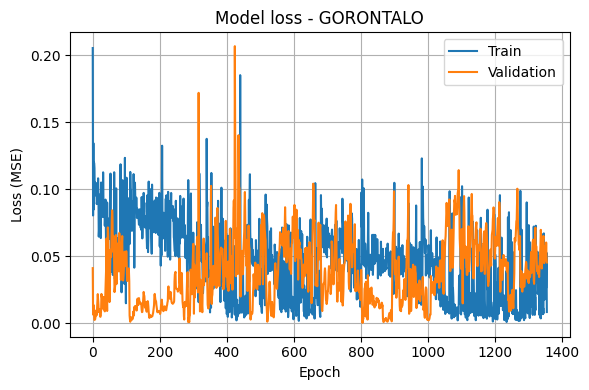

In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive

import os
import random
import numpy as np
import tensorflow as tf

def set_seeds(seed=24):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(24)

drive.mount('/content/drive')

# Load the dataset

!cp "/content/drive/MyDrive/hasil_data_gabungan_DBD_iklim lokal.csv" "./data.csv"
df = pd.read_csv("data.csv")

# Clean and convert data to numeric
for col in ["Kasus DBD", "Curah Hujan", "Kelembapan", "Suhu"]:
    df[col] = df[col].astype(str).str.replace(",", "").str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)

# Create time series sequences
def create_sequences(data, n_steps=2):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps, 1:])  # Features
        y.append(data[i+n_steps, 0])     # Target
    return np.array(X), np.array(y)

# Inverse transform function
def inverse_scale(preds, scaler):
    dummy = np.zeros((len(preds), 3))
    return scaler.inverse_transform(np.hstack((preds, dummy)))[:, 0]

# Model configuration
n_steps = 2
performance_results = []
provinces = df["Nama Provinsi"].unique()

training_histories = {}
for province in provinces:
  # if province == "MALUKU":
  if province == "KALIMANTAN TIMUR" or province == "GORONTALO":
    print(f"\nProcessing: {province}")
    df_prov = df[df["Nama Provinsi"] == province].sort_values("Tahun").copy()

    if len(df_prov) < 5:
        print(f"Skipping {province} due to insufficient data.")
        continue

    # Normalize data
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df_prov[["Kasus DBD", "Curah Hujan", "Kelembapan", "Suhu"]])

    X, y = create_sequences(scaled, n_steps)
    if len(X) < 1:
        print(f"Skipping {province} due to insufficient sequences.")
        continue

    # Split data
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Define 5-layer LSTM model
    model = Sequential()
    model.add(LSTM(8, activation='relu', return_sequences=True, input_shape=(n_steps, X.shape[2])))
    model.add(Dropout(0.2))
    model.add(LSTM(24, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(16, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(16, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(8))  # Final LSTM without return_sequences
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='linear'))

    model.compile(optimizer=Adam(learning_rate=0.0095), loss='mse')

    # Fit model
    early_stop = EarlyStopping(monitor='val_loss', patience=550, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=4000, batch_size=1, verbose=0,
              callbacks=[early_stop], validation_data=(X_test, y_test))
    training_histories[province] = history.history

    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_inv = inverse_scale(y_train.reshape(-1,1), scaler)
    y_train_pred_inv = inverse_scale(y_train_pred, scaler)
    y_test_inv = inverse_scale(y_test.reshape(-1,1), scaler)
    y_test_pred_inv = inverse_scale(y_test_pred, scaler)

    # Metrics
    train_rmse = math.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv))
    train_mae = mean_absolute_error(y_train_inv, y_train_pred_inv)
    test_rmse = math.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))
    test_mae = mean_absolute_error(y_test_inv, y_test_pred_inv)
    train_r2 = r2_score(y_train_inv, y_train_pred_inv)
    test_r2 = r2_score(y_test_inv, y_test_pred_inv)

    performance_results.append({
        'Province': province,
        'Model': 'LSTM_5Layers',
        'Train RMSE': train_rmse,
        'Train MAE': train_mae,
        'Train R2': train_r2,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Test R2': test_r2
    })

# Save results
performance_df = pd.DataFrame(performance_results)
# performance_df.to_csv("performance_results_per_province.csv", index=False)
print("\nPerformance Summary:")
print(performance_df)

# Loop untuk setiap provinsi yang ada di training_histories
for prov, hist in training_histories.items():
    plt.figure(figsize=(6, 4))
    plt.plot(hist['loss'], label='Train')
    plt.plot(hist['val_loss'], label='Validation')
    plt.title(f"Model loss - {prov}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Tampilkan plot
    plt.show()